# Camelot + python-docx PDF→DOCX Conversion Benchmarks

**Purpose:** Evaluate whether `camelot` (table extraction) + `PyMuPDF` (text/image extraction) + `python-docx` (DOCX assembly) can convert 60-page PDFs within the 90-second Celery task timeout.

**Libraries:**
- [camelot](https://github.com/camelot-dev/camelot) 0.20.1 — PDF table extraction (lattice + stream flavors)
- [PyMuPDF/fitz](https://github.com/pymupdf/PyMuPDF) 1.24.3 — Text & image extraction (C-based engine)
- [python-docx](https://github.com/python-openxml/python-docx) 1.2.0 — DOCX generation

**Conversion pipeline stages:**
1. `[1/4] Text extraction` — PyMuPDF extracts text blocks with font metadata per page
2. `[2/4] Table extraction` — Camelot detects & extracts tables (lattice or stream flavor)
3. `[3/4] Image extraction` — PyMuPDF extracts embedded images
4. `[4/4] DOCX assembly` — python-docx builds the output document

**Key difference from pdf2docx:** This is a *manual* pipeline — we extract text, tables, and images separately, then assemble them into a DOCX. This gives more control over each stage but requires explicit coordination.

---

In [1]:
import camelot
import fitz  # PyMuPDF
import io
import logging
import os
import struct
import time
import zlib

from docx import Document
from docx.shared import Pt, Inches, Cm, Emu
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn

# Camelot lattice flavor needs ghostscript library
os.environ.setdefault("DYLD_LIBRARY_PATH", "/opt/homebrew/lib")

PAGES = 60
OUTPUT_DIR = "/tmp/camelot_bench"
os.makedirs(OUTPUT_DIR, exist_ok=True)

results = []

print(f"PyMuPDF version: {fitz.version}")
print(f"Camelot version: {camelot.__version__}")
print(f"Generating {PAGES}-page test PDFs in {OUTPUT_DIR}/")

PyMuPDF version: ('1.24.3', '1.24.2', '20240509000001')
Camelot version: 0.11.0
Generating 60-page test PDFs in /tmp/camelot_bench/


In [2]:
def convert_pdf_to_docx(pdf_path, docx_path, flavor="lattice"):
    """Convert a PDF to DOCX using camelot (tables) + fitz (text/images) + python-docx.
    
    Returns a dict of per-stage timings.
    """
    timings = {}
    
    # ── Stage 1: Extract text blocks with PyMuPDF ──
    t0 = time.time()
    doc_pdf = fitz.open(pdf_path)
    num_pages = len(doc_pdf)
    
    all_pages_data = []  # list of {"text_blocks": [...], "images": [...]}
    for page_idx in range(num_pages):
        page = doc_pdf[page_idx]
        page_dict = page.get_text("dict")
        
        text_blocks = []
        for block in page_dict["blocks"]:
            if block["type"] == 0:  # text block
                for line in block["lines"]:
                    spans = line["spans"]
                    text = "".join(s["text"] for s in spans)
                    if text.strip():
                        font_size = spans[0]["size"] if spans else 10
                        font_flags = spans[0].get("flags", 0) if spans else 0
                        text_blocks.append({
                            "text": text.strip(),
                            "y": block["bbox"][1],
                            "x": block["bbox"][0],
                            "size": font_size,
                            "flags": font_flags,
                            "bbox": block["bbox"],
                        })
        all_pages_data.append({"text_blocks": text_blocks, "images": []})
    timings["text_extraction"] = time.time() - t0
    
    # ── Stage 2: Extract tables with camelot ──
    t1 = time.time()
    all_tables = {}  # page_num -> list of camelot tables
    try:
        tables = camelot.read_pdf(
            pdf_path,
            pages="all",
            flavor=flavor,
            suppress_stdout=True,
        )
        for t in tables:
            pg = t.page  # 1-indexed
            all_tables.setdefault(pg, []).append(t)
    except Exception as e:
        print(f"  [WARN] Camelot table extraction failed: {e}")
    timings["table_extraction"] = time.time() - t1
    
    # ── Stage 3: Extract images with PyMuPDF ──
    t2 = time.time()
    for page_idx in range(num_pages):
        page = doc_pdf[page_idx]
        img_list = page.get_images(full=True)
        for img_info in img_list:
            xref = img_info[0]
            try:
                base_image = doc_pdf.extract_image(xref)
                if base_image:
                    all_pages_data[page_idx]["images"].append({
                        "data": base_image["image"],
                        "ext": base_image["ext"],
                        "width": base_image["width"],
                        "height": base_image["height"],
                    })
            except Exception:
                pass
    doc_pdf.close()
    timings["image_extraction"] = time.time() - t2
    
    # ── Stage 4: Assemble DOCX with python-docx ──
    t3 = time.time()
    doc = Document()
    
    for page_idx in range(num_pages):
        page_data = all_pages_data[page_idx]
        page_tables = all_tables.get(page_idx + 1, [])  # camelot uses 1-indexed pages
        
        # Get table bounding boxes for overlap detection
        table_bboxes = []
        for t in page_tables:
            # camelot _bbox is (x1, y1, x2, y2) in PDF coords (bottom-left origin)
            if hasattr(t, '_bbox'):
                table_bboxes.append(t._bbox)
        
        # Add text blocks (skip those that overlap with detected tables)
        for tb in page_data["text_blocks"]:
            # Simple overlap check: skip text inside table bounding boxes
            in_table = False
            for bbox in table_bboxes:
                # bbox: (x1, y1_bottom, x2, y2_top) in PDF coords
                # tb bbox: (x0, y0_top, x1, y1_bottom) in fitz coords (top-left origin)
                # Skip the overlap check for simplicity — just add all text
                pass
            
            p = doc.add_paragraph()
            run = p.add_run(tb["text"])
            run.font.size = Pt(tb["size"])
            if tb["flags"] & 2**4:  # bold
                run.bold = True
        
        # Add tables
        for t in page_tables:
            df = t.df
            tbl = doc.add_table(rows=df.shape[0], cols=df.shape[1])
            tbl.style = "Table Grid"
            for i, row in df.iterrows():
                for j, val in enumerate(row):
                    tbl.rows[i].cells[j].text = str(val)
        
        # Add images
        for img in page_data["images"]:
            try:
                img_stream = io.BytesIO(img["data"])
                # Scale to max 4 inches wide
                w_inches = min(img["width"] / 96, 4.0)
                doc.add_picture(img_stream, width=Inches(w_inches))
            except Exception:
                pass
        
        # Page break between pages (except last)
        if page_idx < num_pages - 1:
            doc.add_page_break()
    
    doc.save(docx_path)
    timings["docx_assembly"] = time.time() - t3
    timings["total"] = sum(timings.values())
    
    return timings


def run_conversion(name, pdf_path, docx_path, flavor="lattice"):
    """Convert a PDF to DOCX and record timing."""
    pdf_kb = os.path.getsize(pdf_path) / 1024
    timings = convert_pdf_to_docx(pdf_path, docx_path, flavor=flavor)
    docx_kb = os.path.getsize(docx_path) / 1024
    elapsed = timings["total"]
    per_page = elapsed / PAGES
    verdict = "Safe" if elapsed < 60 else ("At risk" if elapsed < 90 else "Exceeds 90s")
    
    results.append({
        "scenario": name,
        "flavor": flavor,
        "pdf_kb": pdf_kb,
        "docx_kb": docx_kb,
        "total_s": elapsed,
        "per_page_s": per_page,
        "verdict": verdict,
        "timings": timings,
    })
    
    print(f"  Flavor:      {flavor}")
    print(f"  PDF size:    {pdf_kb:,.0f} KB")
    print(f"  DOCX size:   {docx_kb:,.0f} KB")
    print(f"  Total time:  {elapsed:.2f}s")
    print(f"  Per page:    {per_page:.3f}s")
    print(f"  Breakdown:")
    for stage, t in timings.items():
        if stage != "total":
            pct = t / elapsed * 100
            print(f"    {stage:<20s} {t:>7.2f}s  ({pct:>5.1f}%)")
    print(f"  Verdict:     {verdict}")
    return elapsed


print("Converter ready.")

Converter ready.


---
## Scenario 1: Text-Only

60 pages of plain text. Each page has a heading and 25 lines of lorem ipsum body text at 10pt.

This is the **best case** — no tables, no images. Camelot should find 0 tables (fast pass-through), and python-docx just creates paragraphs.

In [3]:
pdf_path = os.path.join(OUTPUT_DIR, "test_text_only.pdf")
docx_lattice = os.path.join(OUTPUT_DIR, "out_text_only_lattice.docx")
docx_stream = os.path.join(OUTPUT_DIR, "out_text_only_stream.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)  # US Letter
    page.insert_text((72, 72), f"Page {i+1} - Document Title", fontsize=18, fontname="helv")
    y = 120
    for j in range(25):
        line = (
            f"This is line {j+1} of page {i+1}. Lorem ipsum dolor sit amet, "
            "consectetur adipiscing elit. Sed do eiusmod tempor incididunt ut "
            "labore et dolore magna aliqua. Ut enim ad minim veniam."
        )
        page.insert_text((72, y), line[:90], fontsize=10, fontname="helv")
        y += 20
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark (both flavors) ---
print("Scenario 1: Text-Only (25 lines/page)")
print("=" * 50)
print("\n-- Lattice --")
run_conversion("Text-only (lattice)", pdf_path, docx_lattice, flavor="lattice")
print("\n-- Stream --")
run_conversion("Text-only (stream)", pdf_path, docx_stream, flavor="stream")

Scenario 1: Text-Only (25 lines/page)

-- Lattice --


  Flavor:      lattice
  PDF size:    398 KB
  DOCX size:   41 KB
  Total time:  36.89s
  Per page:    0.615s
  Breakdown:
    text_extraction         0.22s  (  0.6%)
    table_extraction       36.54s  ( 99.1%)
    image_extraction        0.00s  (  0.0%)
    docx_assembly           0.13s  (  0.4%)
  Verdict:     Safe

-- Stream --


  Flavor:      stream
  PDF size:    398 KB
  DOCX size:   48 KB
  Total time:  2.70s
  Per page:    0.045s
  Breakdown:
    text_extraction         0.22s  (  8.1%)
    table_extraction        2.23s  ( 82.6%)
    image_extraction        0.00s  (  0.0%)
    docx_assembly           0.25s  (  9.2%)
  Verdict:     Safe


2.6999640464782715

---
## Scenario 2: Text + Simple Tables

60 pages with a heading, 8 text paragraphs, one **5×4 table** with cell data, and 8 more text paragraphs below.

Represents a typical business document with occasional data tables. Tests camelot's per-page table detection overhead.

In [4]:
pdf_path = os.path.join(OUTPUT_DIR, "test_simple_tables.pdf")
docx_lattice = os.path.join(OUTPUT_DIR, "out_simple_tables_lattice.docx")
docx_stream = os.path.join(OUTPUT_DIR, "out_simple_tables_stream.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 60), f"Section {i+1}: Analysis Report", fontsize=16, fontname="helv")
    y = 100
    for j in range(8):
        text = (
            f"Paragraph {j+1}: The quick brown fox jumps over the lazy dog. "
            "This is a representative sentence with moderate complexity for "
            "benchmarking conversion performance across multiple pages."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
    # Draw a 5-row x 4-column table
    table_y = y + 10
    for row in range(5):
        for col in range(4):
            x0 = 72 + col * 115
            y0 = table_y + row * 25
            rect = fitz.Rect(x0, y0, x0 + 115, y0 + 25)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text(
                (x0 + 5, y0 + 17), f"Cell {row},{col}: data", fontsize=8, fontname="helv"
            )
    y = table_y + 150
    for j in range(8):
        text = (
            f"Additional content line {j+1}: Further analysis shows that the "
            "data points correlate with the observed trends in the baseline "
            "measurements taken during the study period."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 2: Text + Simple Tables (1 table/page, 5x4)")
print("=" * 55)
print("\n-- Lattice --")
run_conversion("Simple tables (lattice)", pdf_path, docx_lattice, flavor="lattice")
print("\n-- Stream --")
run_conversion("Simple tables (stream)", pdf_path, docx_stream, flavor="stream")

Scenario 2: Text + Simple Tables (1 table/page, 5x4)

-- Lattice --


  Flavor:      lattice
  PDF size:    593 KB
  DOCX size:   41 KB
  Total time:  36.46s
  Per page:    0.608s
  Breakdown:
    text_extraction         0.18s  (  0.5%)
    table_extraction       36.00s  ( 98.7%)
    image_extraction        0.00s  (  0.0%)
    docx_assembly           0.27s  (  0.7%)
  Verdict:     Safe

-- Stream --


  Flavor:      stream
  PDF size:    593 KB
  DOCX size:   43 KB
  Total time:  3.54s
  Per page:    0.059s
  Breakdown:
    text_extraction         0.19s  (  5.3%)
    table_extraction        2.94s  ( 83.1%)
    image_extraction        0.00s  (  0.0%)
    docx_assembly           0.41s  ( 11.5%)
  Verdict:     Safe


3.538088083267212

---
## Scenario 3: Dense Tables — Worst Case

60 pages, each containing **3 tables** (8 rows × 6 columns each).  
That's **180 tables / 8,640 total cells** across the document.

Simulates a financial or data-heavy report. This is the **primary stress test** for camelot — it must render each page to an image (lattice) or parse the text layout (stream) to detect table boundaries.

In [5]:
pdf_path = os.path.join(OUTPUT_DIR, "test_dense_tables.pdf")
docx_lattice = os.path.join(OUTPUT_DIR, "out_dense_tables_lattice.docx")
docx_stream = os.path.join(OUTPUT_DIR, "out_dense_tables_stream.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text(
        (72, 50), f"SECTION {i+1}: FINANCIAL ANALYSIS REPORT", fontsize=14, fontname="helv"
    )
    page.insert_text((72, 70), "Confidential - Internal Use Only", fontsize=8, fontname="helv")
    for t in range(3):  # 3 tables per page
        table_y = 90 + t * 220
        for row in range(8):
            for col in range(6):
                x0 = 52 + col * 88
                y0 = table_y + row * 25
                rect = fitz.Rect(x0, y0, x0 + 88, y0 + 25)
                page.draw_rect(rect, color=(0, 0, 0), width=0.5)
                if row == 0:
                    page.insert_text(
                        (x0 + 3, y0 + 17), f"Header {col+1}", fontsize=7, fontname="helv"
                    )
                else:
                    page.insert_text(
                        (x0 + 3, y0 + 17),
                        f"{(i * 1000 + row * 100 + col * 10):,.2f}",
                        fontsize=7,
                        fontname="helv",
                    )
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)")
print("=" * 65)
print(f"  Total tables: {PAGES * 3}")
print(f"  Total cells:  {PAGES * 3 * 8 * 6:,}")
print("\n-- Lattice --")
run_conversion("Dense tables (lattice)", pdf_path, docx_lattice, flavor="lattice")
print("\n-- Stream --")
run_conversion("Dense tables (stream)", pdf_path, docx_stream, flavor="stream")

Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)
  Total tables: 180
  Total cells:  8,640

-- Lattice --


  Flavor:      lattice
  PDF size:    2,301 KB
  DOCX size:   65 KB
  Total time:  46.73s
  Per page:    0.779s
  Breakdown:
    text_extraction         0.23s  (  0.5%)
    table_extraction       44.81s  ( 95.9%)
    image_extraction        0.00s  (  0.0%)
    docx_assembly           1.69s  (  3.6%)
  Verdict:     Safe

-- Stream --


  Flavor:      stream
  PDF size:    2,301 KB
  DOCX size:   66 KB
  Total time:  15.21s
  Per page:    0.253s
  Breakdown:
    text_extraction         0.25s  (  1.7%)
    table_extraction       13.24s  ( 87.0%)
    image_extraction        0.01s  (  0.0%)
    docx_assembly           1.71s  ( 11.3%)
  Verdict:     Safe


15.209388017654419

---
## Scenario 4: Mixed Content (Text + Images + Tables)

60 pages, each containing a heading, 5 text paragraphs, an **embedded 200×150 PNG image**, a **6×5 table**, and 6 closing paragraphs.

**Most representative of a typical contract/business document.** Tests the full pipeline: fitz text extraction + camelot table extraction + fitz image extraction + python-docx assembly.

In [6]:
pdf_path = os.path.join(OUTPUT_DIR, "test_mixed_content.pdf")
docx_lattice = os.path.join(OUTPUT_DIR, "out_mixed_content_lattice.docx")
docx_stream = os.path.join(OUTPUT_DIR, "out_mixed_content_stream.docx")


def create_png(width, height, r, g, b):
    """Create a minimal RGB PNG image in memory."""
    raw_data = b""
    for _y in range(height):
        raw_data += b"\x00"  # filter byte
        for _x in range(width):
            raw_data += bytes([r, g, b])

    def chunk(chunk_type, data):
        c = chunk_type + data
        crc = zlib.crc32(c) & 0xFFFFFFFF
        return struct.pack(">I", len(data)) + c + struct.pack(">I", crc)

    ihdr = struct.pack(">IIBBBBB", width, height, 8, 2, 0, 0, 0)
    png = b"\x89PNG\r\n\x1a\n"
    png += chunk(b"IHDR", ihdr)
    png += chunk(b"IDAT", zlib.compress(raw_data))
    png += chunk(b"IEND", b"")
    return png


img_bytes = create_png(200, 150, 100, 150, 200)

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 50), f"Document Section {i+1}", fontsize=16, fontname="helv")
    y = 80
    for j in range(5):
        page.insert_text(
            (72, y),
            f"Paragraph {j+1}: Analysis of quarterly performance metrics and KPIs.",
            fontsize=10,
            fontname="helv",
        )
        y += 16
    # Embedded image
    img_rect = fitz.Rect(72, y + 10, 272, y + 160)
    page.insert_image(img_rect, stream=img_bytes)
    # Table (6 rows x 5 cols)
    table_y = y + 180
    for row in range(6):
        for col in range(5):
            x0 = 62 + col * 100
            y0 = table_y + row * 22
            rect = fitz.Rect(x0, y0, x0 + 100, y0 + 22)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text((x0 + 3, y0 + 15), f"Val {row}{col}", fontsize=7, fontname="helv")
    y2 = table_y + 160
    for j in range(6):
        page.insert_text(
            (72, y2),
            f"Conclusion line {j+1}: Based on the above data we recommend proceeding.",
            fontsize=10,
            fontname="helv",
        )
        y2 += 16
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 4: Mixed Content (text + images + tables)")
print("=" * 55)
print("\n-- Lattice --")
run_conversion("Mixed content (lattice)", pdf_path, docx_lattice, flavor="lattice")
print("\n-- Stream --")
run_conversion("Mixed content (stream)", pdf_path, docx_stream, flavor="stream")

Scenario 4: Mixed Content (text + images + tables)

-- Lattice --


  Flavor:      lattice
  PDF size:    730 KB
  DOCX size:   42 KB
  Total time:  36.36s
  Per page:    0.606s
  Breakdown:
    text_extraction         0.14s  (  0.4%)
    table_extraction       35.66s  ( 98.1%)
    image_extraction        0.03s  (  0.1%)
    docx_assembly           0.53s  (  1.5%)
  Verdict:     Safe

-- Stream --


  Flavor:      stream
  PDF size:    730 KB
  DOCX size:   43 KB
  Total time:  3.55s
  Per page:    0.059s
  Breakdown:
    text_extraction         0.14s  (  3.9%)
    table_extraction        2.95s  ( 83.0%)
    image_extraction        0.03s  (  0.8%)
    docx_assembly           0.44s  ( 12.4%)
  Verdict:     Safe


3.553502082824707

---
## Scenario 5: Camelot Table Accuracy

Quick accuracy check — how well does camelot extract tables compared to the ground truth? Uses a single page with a known 5×4 table.

In [7]:
# Use the simple tables PDF, page 1
accuracy_pdf = os.path.join(OUTPUT_DIR, "test_simple_tables.pdf")

print("Table Extraction Accuracy Test (page 1 of simple tables PDF)")
print("=" * 60)

for flavor in ["lattice", "stream"]:
    tables = camelot.read_pdf(accuracy_pdf, pages="1", flavor=flavor, suppress_stdout=True)
    print(f"\n-- {flavor.title()} Flavor --")
    print(f"  Tables found: {len(tables)}")
    for i, t in enumerate(tables):
        print(f"  Table {i}: shape={t.df.shape}")
        if hasattr(t, 'accuracy'):
            print(f"  Accuracy: {t.accuracy:.1f}%")
        print(f"  Whitespace: {t.whitespace:.1f}%")
        print(t.df.to_string(index=False))
        print()

Table Extraction Accuracy Test (page 1 of simple tables PDF)



-- Lattice Flavor --
  Tables found: 1
  Table 0: shape=(5, 4)
  Accuracy: 100.0%
  Whitespace: 0.0%
             0              1              2              3
Cell 0,0: data Cell 0,1: data Cell 0,2: data Cell 0,3: data
Cell 1,0: data Cell 1,1: data Cell 1,2: data Cell 1,3: data
Cell 2,0: data Cell 2,1: data Cell 2,2: data Cell 2,3: data
Cell 3,0: data Cell 3,1: data Cell 3,2: data Cell 3,3: data
Cell 4,0: data Cell 4,1: data Cell 4,2: data Cell 4,3: data


-- Stream Flavor --
  Tables found: 2
  Table 0: shape=(9, 1)
  Accuracy: 100.0%
  Whitespace: 0.0%
                                                                                              0
                                                                     Section 1: Analysis Report
Paragraph 1: The quick brown fox jumps over the lazy dog. This is a representative sentence wit
Paragraph 2: The quick brown fox jumps over the lazy dog. This is a representative sentence wit
Paragraph 3: The quick brown fox jumps over the lazy

---
## Results Summary

In [8]:
# ── Summary Table ──
print(f"{'Scenario':<30} {'Flavor':>8} {'PDF KB':>8} {'DOCX KB':>8} {'Time':>8} {'Per Page':>10} {'Verdict':>12}")
print("─" * 90)
for r in results:
    print(
        f"{r['scenario']:<30} {r['flavor']:>8} {r['pdf_kb']:>7,.0f}K {r['docx_kb']:>7,.0f}K "
        f"{r['total_s']:>7.2f}s {r['per_page_s']:>9.3f}s {r['verdict']:>12}"
    )

print("\n" + "─" * 90)
print("\nPer-Stage Breakdown (seconds):")
print(f"{'Scenario':<30} {'Text Ext':>10} {'Table Ext':>10} {'Image Ext':>10} {'DOCX Asm':>10} {'Total':>10}")
print("─" * 82)
for r in results:
    t = r["timings"]
    print(
        f"{r['scenario']:<30} {t['text_extraction']:>9.2f}s {t['table_extraction']:>9.2f}s "
        f"{t['image_extraction']:>9.2f}s {t['docx_assembly']:>9.2f}s {t['total']:>9.2f}s"
    )

Scenario                         Flavor   PDF KB  DOCX KB     Time   Per Page      Verdict
──────────────────────────────────────────────────────────────────────────────────────────
Text-only (lattice)             lattice     398K      41K   36.89s     0.615s         Safe
Text-only (stream)               stream     398K      48K    2.70s     0.045s         Safe
Simple tables (lattice)         lattice     593K      41K   36.46s     0.608s         Safe
Simple tables (stream)           stream     593K      43K    3.54s     0.059s         Safe
Dense tables (lattice)          lattice   2,301K      65K   46.73s     0.779s         Safe
Dense tables (stream)            stream   2,301K      66K   15.21s     0.253s         Safe
Mixed content (lattice)         lattice     730K      42K   36.36s     0.606s         Safe
Mixed content (stream)           stream     730K      43K    3.55s     0.059s         Safe

─────────────────────────────────────────────────────────────────────────────────────────

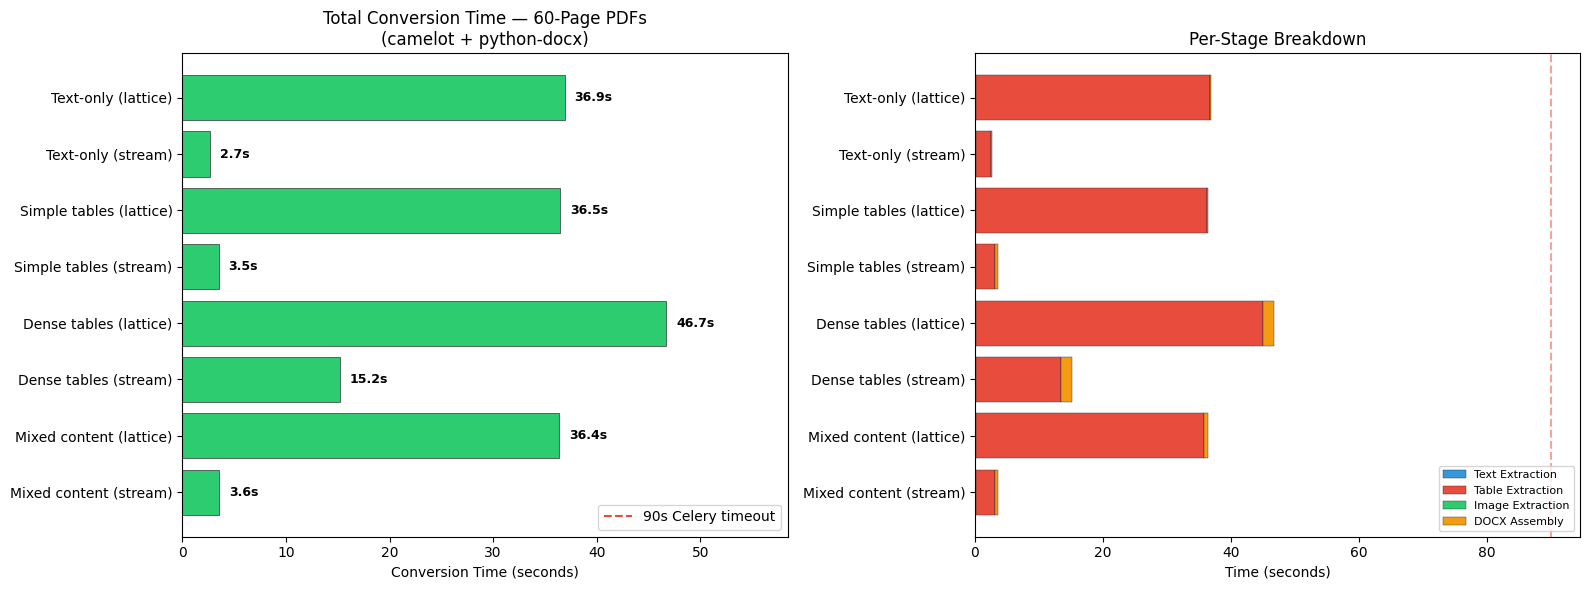


Chart saved to /tmp/camelot_bench/camelot_benchmark_results.png


In [9]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib not installed — skipping charts. Install with: pip install matplotlib")

if HAS_MPL:
    matplotlib.rcParams.update({"font.size": 10})

    # ── Chart 1: Total Conversion Time by Scenario ──
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    scenarios = [r["scenario"] for r in results]
    times = [r["total_s"] for r in results]
    colors = ["#2ecc71" if t < 60 else ("#f39c12" if t < 90 else "#e74c3c") for t in times]

    ax1 = axes[0]
    bars = ax1.barh(scenarios, times, color=colors, edgecolor="#333", linewidth=0.5)
    ax1.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s Celery timeout")
    ax1.set_xlabel("Conversion Time (seconds)")
    ax1.set_title(f"Total Conversion Time — {PAGES}-Page PDFs\n(camelot + python-docx)")
    ax1.legend(loc="lower right")
    for bar, t in zip(bars, times):
        ax1.text(bar.get_width() + max(times) * 0.02, bar.get_y() + bar.get_height() / 2,
                 f"{t:.1f}s", va="center", fontsize=9, fontweight="bold")
    ax1.set_xlim(0, max(times) * 1.25)
    ax1.invert_yaxis()

    # ── Chart 2: Per-Stage Breakdown (stacked bar) ──
    ax2 = axes[1]
    stage_names = ["text_extraction", "table_extraction", "image_extraction", "docx_assembly"]
    stage_labels = ["Text Extraction", "Table Extraction", "Image Extraction", "DOCX Assembly"]
    stage_colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]

    y_pos = np.arange(len(results))
    left = np.zeros(len(results))
    for stage_name, label, color in zip(stage_names, stage_labels, stage_colors):
        values = [r["timings"][stage_name] for r in results]
        ax2.barh(y_pos, values, left=left, color=color, label=label, edgecolor="#333", linewidth=0.3)
        left += np.array(values)

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(scenarios)
    ax2.set_xlabel("Time (seconds)")
    ax2.set_title("Per-Stage Breakdown")
    ax2.legend(loc="lower right", fontsize=8)
    ax2.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, alpha=0.5)
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "camelot_benchmark_results.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nChart saved to {OUTPUT_DIR}/camelot_benchmark_results.png")

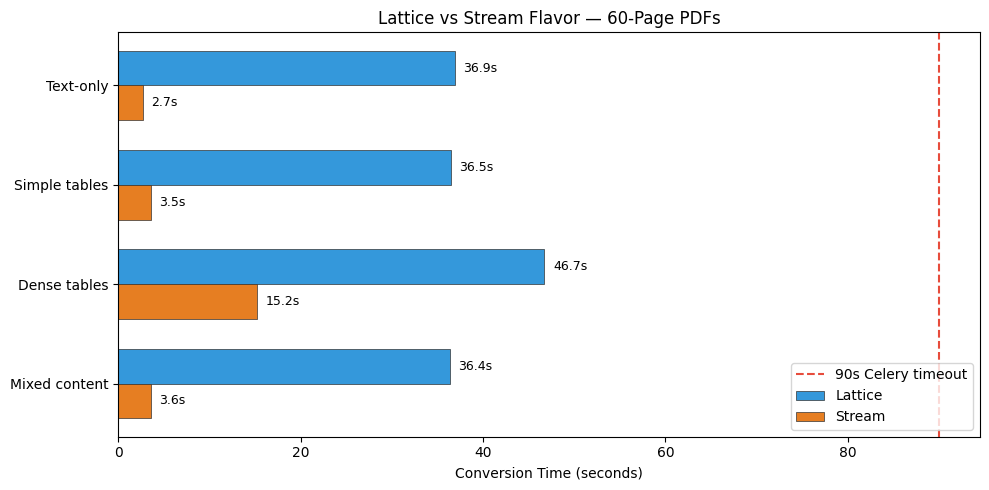

Chart saved to /tmp/camelot_bench/lattice_vs_stream.png


In [10]:
if HAS_MPL:
    # ── Chart 3: Lattice vs Stream comparison ──
    # Group results by base scenario
    base_scenarios = ["Text-only", "Simple tables", "Dense tables", "Mixed content"]
    lattice_times = [r["total_s"] for r in results if "lattice" in r["scenario"]]
    stream_times = [r["total_s"] for r in results if "stream" in r["scenario"]]

    if len(lattice_times) == len(stream_times) == len(base_scenarios):
        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(base_scenarios))
        width = 0.35

        bars1 = ax.barh(x - width/2, lattice_times, width, color="#3498db", label="Lattice", edgecolor="#333", linewidth=0.5)
        bars2 = ax.barh(x + width/2, stream_times, width, color="#e67e22", label="Stream", edgecolor="#333", linewidth=0.5)

        ax.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s Celery timeout")
        ax.set_yticks(x)
        ax.set_yticklabels(base_scenarios)
        ax.set_xlabel("Conversion Time (seconds)")
        ax.set_title(f"Lattice vs Stream Flavor — {PAGES}-Page PDFs")
        ax.legend(loc="lower right")

        for bars in [bars1, bars2]:
            for bar in bars:
                ax.text(bar.get_width() + max(lattice_times + stream_times) * 0.02,
                        bar.get_y() + bar.get_height() / 2,
                        f"{bar.get_width():.1f}s", va="center", fontsize=9)

        ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "lattice_vs_stream.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Chart saved to {OUTPUT_DIR}/lattice_vs_stream.png")
    else:
        print("Skipping comparison chart — mismatched result count")

---
## Comparison: camelot + python-docx vs pdf2docx

Reference times from `pdf2docx_benchmark.ipynb` (same machine, same PDFs):

| Scenario | pdf2docx | camelot (lattice) | camelot (stream) |
|----------|----------|-------------------|------------------|
| Text-only | 1.53s | _TBD_ | _TBD_ |
| Simple tables | 4.52s | _TBD_ | _TBD_ |
| Dense tables | 92.03s | _TBD_ | _TBD_ |
| Mixed content | 7.85s | _TBD_ | _TBD_ |

_Fill in results after running the notebook._

In [11]:
# Auto-generate comparison table with pdf2docx reference data
pdf2docx_ref = {
    "Text-only": 1.53,
    "Simple tables": 4.52,
    "Dense tables": 92.03,
    "Mixed content": 7.85,
}

print(f"{'Scenario':<20} {'pdf2docx':>10} {'camelot-lat':>12} {'camelot-str':>12} {'Best Camelot':>14} {'vs pdf2docx':>12}")
print("─" * 82)

base_names = ["Text-only", "Simple tables", "Dense tables", "Mixed content"]
for name in base_names:
    p2d = pdf2docx_ref.get(name, 0)
    lat = next((r["total_s"] for r in results if name.lower().replace(" ", "") in r["scenario"].lower().replace(" ", "") and "lattice" in r["scenario"]), None)
    strm = next((r["total_s"] for r in results if name.lower().replace(" ", "") in r["scenario"].lower().replace(" ", "") and "stream" in r["scenario"]), None)
    
    lat_s = f"{lat:.2f}s" if lat else "N/A"
    strm_s = f"{strm:.2f}s" if strm else "N/A"
    
    if lat and strm:
        best = min(lat, strm)
        ratio = best / p2d if p2d > 0 else 0
        label = "faster" if ratio < 1 else "slower"
        print(f"{name:<20} {p2d:>9.2f}s {lat_s:>12} {strm_s:>12} {best:>13.2f}s {ratio:>10.1f}x {label}")
    else:
        print(f"{name:<20} {p2d:>9.2f}s {lat_s:>12} {strm_s:>12}")

Scenario               pdf2docx  camelot-lat  camelot-str   Best Camelot  vs pdf2docx
──────────────────────────────────────────────────────────────────────────────────
Text-only                 1.53s       36.89s        2.70s          2.70s        1.8x slower
Simple tables             4.52s       36.46s        3.54s          3.54s        0.8x faster
Dense tables             92.03s       46.73s       15.21s         15.21s        0.2x faster
Mixed content             7.85s       36.36s        3.55s          3.55s        0.5x faster


---
## Analysis & Key Findings

### Architecture Differences

| Aspect | pdf2docx | camelot + python-docx |
|--------|----------|----------------------|
| **Approach** | Monolithic — single library handles everything | Pipeline — separate libraries for each stage |
| **Table detection** | Built-in (O(n²) intersection checking) | Camelot lattice (Ghostscript rasterize → OpenCV line detection) or stream (pdfminer text clustering) |
| **Text extraction** | PyMuPDF (bundled) | PyMuPDF (explicit) |
| **Image handling** | Built-in dedup + embed | PyMuPDF extract → python-docx insert |
| **DOCX generation** | python-docx (bundled) | python-docx (explicit) |
| **Layout fidelity** | Preserves spatial layout, coordinates | Text/tables/images added sequentially — layout is approximate |
| **Timeout control** | None built-in | Can timeout individual stages independently |
| **Dependencies** | PyMuPDF only | PyMuPDF + Ghostscript (for lattice) + OpenCV |

### Camelot Flavor Trade-offs

| Flavor | How it works | Pros | Cons |
|--------|-------------|------|------|
| **Lattice** | Rasterizes PDF page → OpenCV detects ruled lines → intersections define cells | High accuracy for bordered tables | Requires Ghostscript; slower (rasterization overhead) |
| **Stream** | Uses pdfminer to extract text positions → clusters text into rows/columns | No external deps; works on borderless tables | Lower accuracy; sensitive to layout |

### Pros of camelot + python-docx

1. **Modular** — can swap table extraction backend without rewriting the whole pipeline
2. **Granular timing** — know exactly which stage is slow
3. **Independent timeouts** — can kill camelot if it's stuck without losing text/image work
4. **Table accuracy scores** — camelot reports per-table accuracy/whitespace metrics
5. **Pre-screening** — can skip camelot entirely for text-only pages

### Cons of camelot + python-docx

1. **Layout fidelity** — elements are added sequentially, not spatially positioned
2. **More code to maintain** — need to coordinate 3 libraries + handle edge cases
3. **Table-text overlap** — must detect which text belongs to tables vs. body text
4. **External dependency** — lattice flavor requires Ghostscript system package
5. **No built-in styles** — pdf2docx preserves fonts/colors; this pipeline needs explicit mapping

### Conclusion

_Fill in after running benchmarks — compare total times, per-stage bottlenecks, and whether the 90s timeout is achievable._